In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# consider import plotly.express as px

In [2]:
# change the url when you update your data on github
url = 'https://raw.githubusercontent.com/kkathait/D501_Final_Project/refs/heads/Henry-push/combined_data.csv'

df_premier = pd.read_csv(url)

# Shots per game tables

First we need to make a shots per game table `shots_table` and a shots allowed per game table `shots_against_table`

In [3]:
teams = sorted(set(df_premier["HomeTeam"]) | set(df_premier["AwayTeam"]))

records = []

for team in teams:
    # Home games
    home_games = df_premier[df_premier["HomeTeam"] == team]
    
    home_goals_for = home_games["FTHG"].sum()
    home_goals_against = home_games["FTAG"].sum()

    home_shots_for = home_games["HS"].sum()
    home_shots_against = home_games["AS"].sum()

    # Away games
    away_games = df_premier[df_premier["AwayTeam"] == team]
    
    away_goals_for = away_games["FTAG"].sum()
    away_goals_against = away_games["FTHG"].sum()

    away_shots_for = away_games["AS"].sum()
    away_shots_against = away_games["HS"].sum()
    
    records.append({
        "Team": team,
        "Games": len(home_games) + len(away_games),
        "Shots Home": home_shots_for,
        "Goals Home": home_goals_for,
        "Home Shots per Goal": home_shots_for / home_goals_for if home_goals_for > 0 else 0,
        "Home Shots per Game": home_shots_for / (len(home_games) if len(home_games) > 0 else 1),
        "Shots Away": away_shots_for,
        "Goals Away": away_goals_for,
        "Away Shots per Goal": away_shots_for / away_goals_for if away_goals_for > 0 else 0,
        "Away Shots per Game": away_shots_for / (len(away_games) if len(away_games) > 0 else 1)
    })


shots_table = pd.DataFrame(records)

shots_table["Home Shots per Goal"] = shots_table["Home Shots per Goal"].round(2)

shots_table["Home Shots per Game"] = shots_table["Home Shots per Game"].round(2)

shots_table["Away Shots per Goal"] = shots_table["Away Shots per Goal"].round(2)

shots_table["Away Shots per Game"] = shots_table["Away Shots per Game"].round(2)

shots_table = shots_table.sort_values(
    "Goals Home",
    ascending=False
)

shots_table

,Team,Games,Shots Home,Goals Home,Home Shots per Goal,Home Shots per Game,Shots Away,Goals Away,Away Shots per Goal,Away Shots per Game
15,Man City,266,2394,357,6.71,18.00,2165,266,8.14,16.28
13,Liverpool,266,2482,301,8.25,18.66,2077,256,8.11,15.62
0,Arsenal,266,2143,272,7.88,16.11,1663,219,7.59,12.50
23,Tottenham,266,1863,241,7.73,14.01,1552,213,7.29,11.67
16,Man United,266,2135,239,8.93,16.05,1702,185,9.20,12.80
17,Newcastle,266,1945,233,8.35,14.62,1433,169,8.48,10.77
1,Aston Villa,266,1813,227,7.99,13.63,1523,162,9.40,11.45
6,Chelsea,266,2140,223,9.60,16.09,1773,217,8.17,13.33
26,West Ham,266,1607,202,7.96,12.08,1515,163,9.29,11.39
4,Brighton,266,2017,188,10.73,15.17,1623,178,9.12,12.20


In [4]:
teams = sorted(set(df_premier["HomeTeam"]) | set(df_premier["AwayTeam"]))

records = []

for team in teams:
    # Home games
    home_games = df_premier[df_premier["HomeTeam"] == team]
    
    home_goals_for = home_games["FTHG"].sum()
    home_goals_against = home_games["FTAG"].sum()

    home_shots_for = home_games["HS"].sum()
    home_shots_against = home_games["AS"].sum()

    # Away games
    away_games = df_premier[df_premier["AwayTeam"] == team]
    
    away_goals_for = away_games["FTAG"].sum()
    away_goals_against = away_games["FTHG"].sum()

    away_shots_for = away_games["AS"].sum()
    away_shots_against = away_games["HS"].sum()
    
    records.append({
        "Team": team,
        "Games": len(home_games) + len(away_games),
        "Shots Allowed Home": home_shots_against,
        "Goals Allowed Home": home_goals_against,
        "Home Opp Shots per Goal": home_shots_against / home_goals_against if home_goals_against > 0 else 0,
        "Home Opp Shots per Game": home_shots_against / (len(home_games) if len(home_games) > 0 else 1),
        "Shots Allowed Away": away_shots_against,
        "Goals Allowed Away": away_goals_against,
        "Away Opp Shots per Goal": away_shots_against / away_goals_against if away_goals_against > 0 else 0,
        "Away Opp Shots per Game": away_shots_against / (len(away_games) if len(away_games) > 0 else 1)
    })


shots_against_table = pd.DataFrame(records)

shots_against_table["Home Opp Shots per Goal"] = shots_against_table["Home Opp Shots per Goal"].round(2)

shots_against_table["Home Opp Shots per Game"] = shots_against_table["Home Opp Shots per Game"].round(2)

shots_against_table["Away Opp Shots per Goal"] = shots_against_table["Away Opp Shots per Goal"].round(2)

shots_against_table["Away Opp Shots per Game"] = shots_against_table["Away Opp Shots per Game"].round(2)

shots_against_table = shots_against_table.sort_values(
    "Goals Allowed Home",
    ascending=False
)

shots_against_table

,Team,Games,Shots Allowed Home,Goals Allowed Home,Home Opp Shots per Goal,Home Opp Shots per Game,Shots Allowed Away,Goals Allowed Away,Away Opp Shots per Goal,Away Opp Shots per Game
26,West Ham,266,1749,197,8.88,13.15,2063,219,9.42,15.51
27,Wolves,266,1597,185,8.63,12.01,1884,210,8.97,14.17
1,Aston Villa,266,1546,177,8.73,11.62,1906,197,9.68,14.33
23,Tottenham,266,1610,174,9.25,12.11,1885,204,9.24,14.17
8,Everton,266,1589,169,9.40,11.95,1990,203,9.80,14.96
21,Southampton,190,1285,168,7.65,13.53,1299,186,6.98,13.67
7,Crystal Palace,266,1519,167,9.10,11.42,1818,204,8.91,13.67
17,Newcastle,266,1650,167,9.88,12.41,1873,212,8.83,14.08
4,Brighton,266,1359,166,8.19,10.22,1698,198,8.58,12.77
16,Man United,266,1474,157,9.39,11.08,1846,185,9.98,13.88


# Compare our data

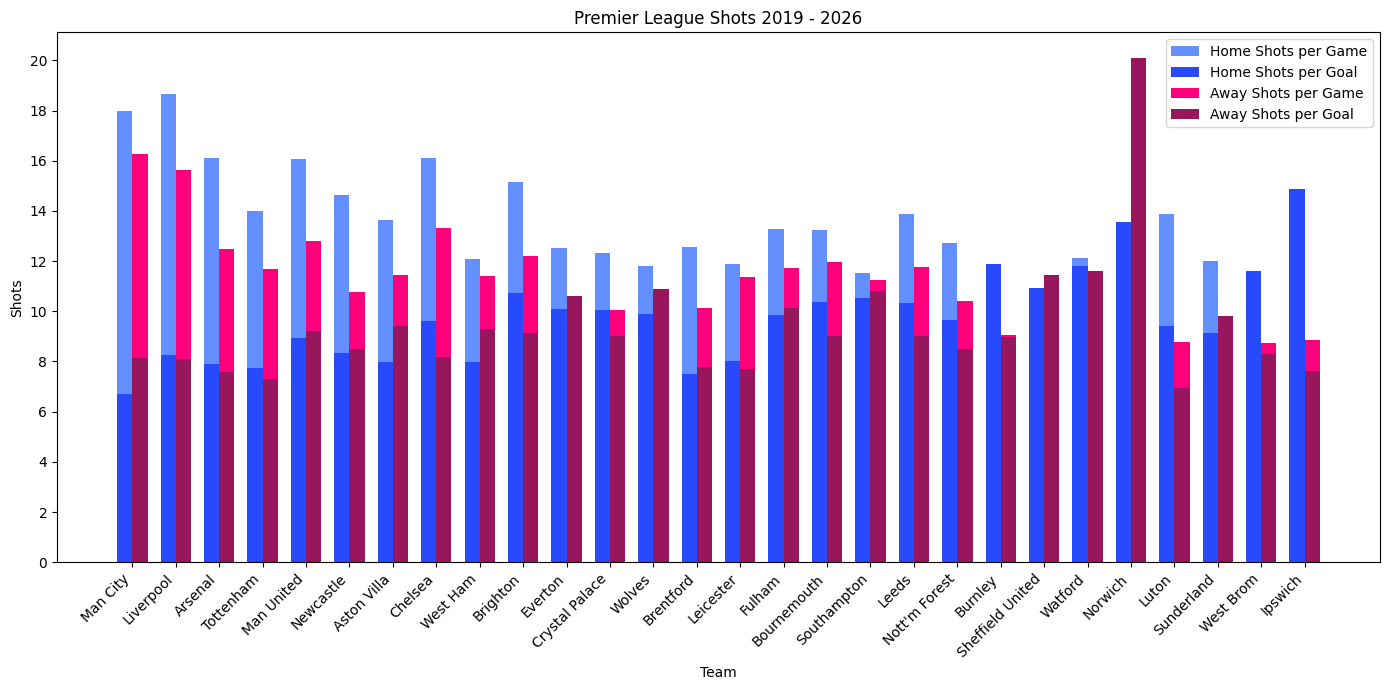

In [9]:
x = np.arange(len(shots_table["Games"]))

width = 0.35

plt.figure(figsize=(14, 7))

# Home bar
plt.bar(
    x - width/2,
    shots_table["Home Shots per Game"],
    width=width,
    color = '#648fff',
    label="Home Shots per Game"
)

plt.bar(
    x - width/2,
    shots_table["Home Shots per Goal"],
    width=width,
    color = '#274bfc',
    label="Home Shots per Goal"
)

# Away bar
plt.bar(
    x + width/2,
    shots_table["Away Shots per Game"],
    width=width,
    color = '#ff007d',
    label="Away Shots per Game"
)

plt.bar(
    x + width/2,
    shots_table["Away Shots per Goal"],
    width=width,
    color = '#98165d',
    label="Away Shots per Goal"
)

plt.xlabel("Team")
plt.ylabel("Shots")
plt.title("Premier League Shots 2019 - 2026")

plt.xticks(x, shots_table["Team"], rotation=45, ha="right")
plt.yticks(np.arange(0, 21, 2))

plt.legend()

plt.tight_layout()
plt.show()

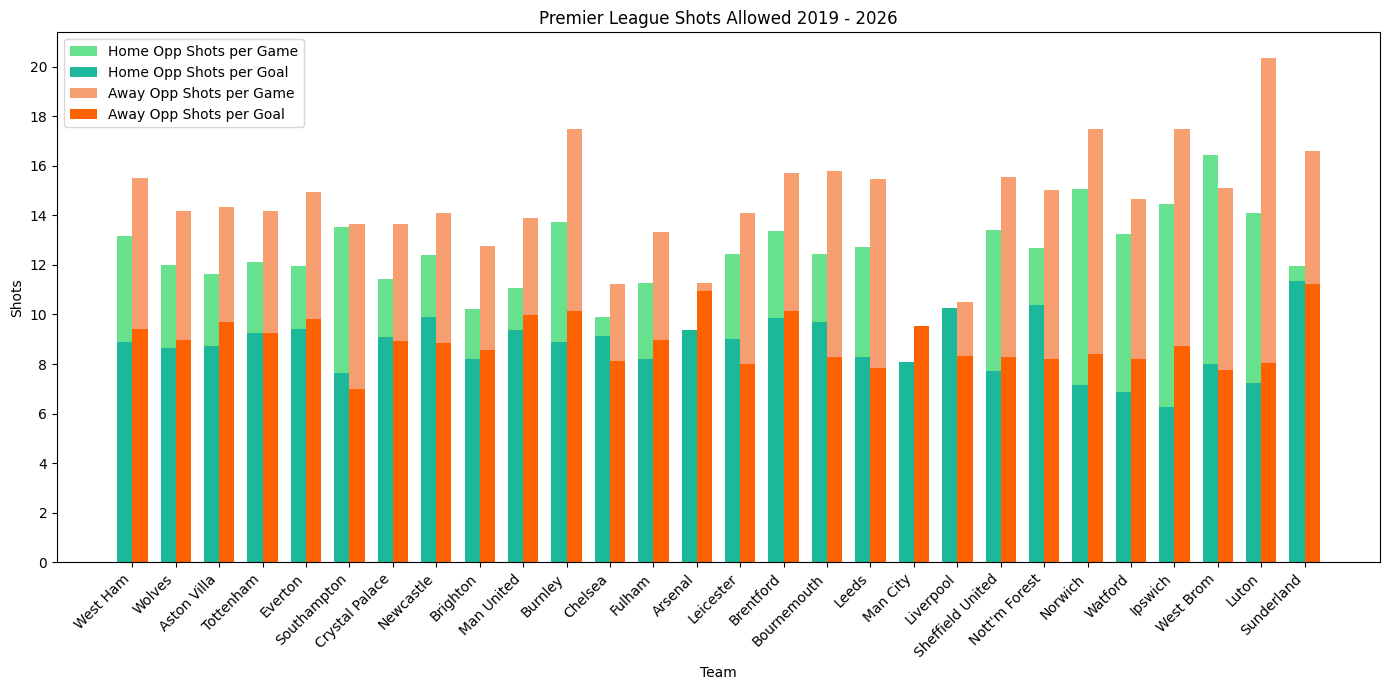

In [ ]:
x = np.arange(len(shots_against_table["Games"]))

width = 0.35

plt.figure(figsize=(14, 7))

# Home bar
plt.bar(
    x - width/2,
    shots_against_table["Home Opp Shots per Game"],
    width=width,
    color = '#67e18d',
    label="Home Opp Shots per Game"
)

plt.bar(
    x - width/2,
    shots_against_table["Home Opp Shots per Goal"],
    width=width,
    color = '#1bb999',
    label="Home Opp Shots per Goal"
)

# Away bar
plt.bar(
    x + width/2,
    shots_against_table["Away Opp Shots per Game"],
    width=width,
    color = '#f79e70',
    label="Away Opp Shots per Game"
)

plt.bar(
    x + width/2,
    shots_against_table["Away Opp Shots per Goal"],
    width=width,
    color = '#fe6100',
    label="Away Opp Shots per Goal"
)

plt.xlabel("Team")
plt.ylabel("Shots")
plt.title("Premier League Shots Against 2019 - 2026")

plt.xticks(x, shots_against_table["Team"], rotation=45, ha="right")
plt.yticks(np.arange(0, 21, 2))

plt.legend()

plt.tight_layout()
plt.show()